# Model Training & Evaluation — C-MAPSS FD001
Baseline comparison of Linear Regression, Random Forest, and XGBoost for RUL prediction.

1. Import Libraries & Project Modules

In [1]:
# standard
from pathlib import Path

# 3rd party
import pandas as pd

# project
from xai_aviation_rul.data_loader import load_cmapss
from xai_aviation_rul.models import (
    evaluate_model,
    save_model,
    train_linear_regression,
    train_random_forest,
    train_xgboost,
)
from xai_aviation_rul.preprocessor import (
    compute_rul,
    drop_constant_sensors,
    get_last_cycle,
    normalize,
)
from xai_aviation_rul.visualizer import (
    save_results_table,
)

# figure save paths
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

2. Prepare Data

In [2]:
# load raw train and test sets
df_train = load_cmapss(fd=1, subset="train")
df_test = load_cmapss(fd=1, subset="test")

# load ground truth RUL for test engines
rul_true = pd.read_csv(
    "../data/CMAPSS_dataset/RUL_FD001.txt", header=None, names=["RUL"]
)

# compute RUL labels
df_train = compute_rul(df_train, rul_cap=125)

# remove constant sensors
df_train = drop_constant_sensors(df_train, threshold=0.01)

# fit scaler on train, apply to both train and test
df_train, df_test, scaler = normalize(df_train, df_test)

# feature columns
sensor_cols = [c for c in df_train.columns if c.startswith("sensor_")]

# training features and target
X_train = df_train[sensor_cols]
y_train = df_train["RUL_capped"]

# test features
df_last = get_last_cycle(df_test)
X_test = df_last[sensor_cols]
y_test = rul_true["RUL"]

3. Train Models

In [3]:
# models training
lr_model = train_linear_regression(X_train, y_train)
rf_model = train_random_forest(X_train, y_train)
xgb_model = train_xgboost(X_train, y_train)

4. Evaluate & Save Models

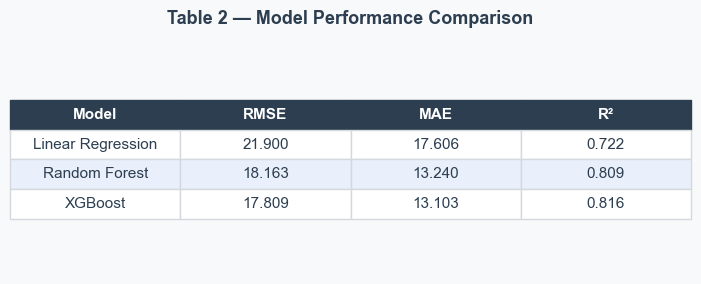

Models saved.


In [4]:
# model evaluation 
results = {
    "Linear Regression": evaluate_model(lr_model, X_test, y_test),
    "Random Forest":     evaluate_model(rf_model, X_test, y_test),
    "XGBoost":           evaluate_model(xgb_model, X_test, y_test),
}

results_table = pd.DataFrame(results).T.round(3)
results_table.index.name = "Model"

# model saving and results visualization
save_results_table(
    results_table,
    save_path=FIG_DIR / "table2_model_comparison.png",
    title="Table 2 — Model Performance Comparison"
)

# save models
save_model(xgb_model, MODEL_DIR / "xgboost_model.pkl")
save_model(scaler, MODEL_DIR / "scaler.pkl")
print("Models saved.")